1. Project Introduction
2. Import Libraries
3. Define Data Parameters
4. Download Gold Price Data
5. Initial Inspection
6. Save Raw Data


# Gold Volatility Analysis

## Objective

This project analyzes the historical price behavior and volatility of gold.

The main objectives are:

- Analyze historical gold prices
- Calculate daily and log returns
- Measure historical and rolling volatility
- Investigate volatility clustering
- Model volatility using GARCH
- Evaluate market risk using VaR and Expected Shortfall

The analysis is designed as a financial analytics and quantitative research project.

## Phase 1 — Data Collection

In this phase, historical gold price data is collected and stored as raw data.

No financial transformations are performed at this stage.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yfinance as yf
from arch import arch_model

In [2]:
BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "Data" / "raw"
PROCESSED_DIR = BASE_DIR / "Data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data path:", RAW_DIR)
print("Processed data path:", PROCESSED_DIR)

Raw data path: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\raw
Processed data path: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed


## Download Gold Futures Data

Gold futures historical data is collected from Yahoo Finance using
the ticker symbol `GC=F`.

The dataset contains daily OHLC prices, adjusted closing price,
and trading volume.

In [4]:
ticker = "GC=F"

gold_df = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False
)

gold_df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


In [5]:
print("Shape:", gold_df.shape)
print("\nColumns:")
print(gold_df.columns)

print("\nMissing Values:")
print(gold_df.isnull().sum())

gold_df.info()

Shape: (4207, 6)

Columns:
MultiIndex([('Adj Close', 'GC=F'),
            (    'Close', 'GC=F'),
            (     'High', 'GC=F'),
            (      'Low', 'GC=F'),
            (     'Open', 'GC=F'),
            (   'Volume', 'GC=F')],
           names=['Price', 'Ticker'])

Missing Values:
Price      Ticker
Adj Close  GC=F      0
Close      GC=F      0
High       GC=F      0
Low        GC=F      0
Open       GC=F      0
Volume     GC=F      0
dtype: int64
<class 'pandas.DataFrame'>
DatetimeIndex: 4207 entries, 2010-01-04 to 2026-09-24
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, GC=F)  4207 non-null   float64
 1   (Close, GC=F)      4207 non-null   float64
 2   (High, GC=F)       4207 non-null   float64
 3   (Low, GC=F)        4207 non-null   float64
 4   (Open, GC=F)       4207 non-null   float64
 5   (Volume, GC=F)     4207 non-null   int64  
dtypes: float64(5), int64(1)
memory usage

In [6]:
display(gold_df.head())

display(gold_df.tail())

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2026-09-18,4424.899902,4424.899902,4439.799805,4372.200195,4381.600098,142919
2026-09-21,4383.899902,4383.899902,4422.100098,4360.299805,4413.000000,138203
2026-09-22,4376.399902,4376.399902,4414.100098,4327.600098,4382.500000,178132
2026-09-23,4318.399902,4318.399902,4407.500000,4310.700195,4394.700195,178132
2026-09-24,4307.399902,4307.399902,4338.000000,4278.299805,4324.399902,158403


In [7]:
output_file = RAW_DIR / "gold_price.csv"

gold_df.to_csv(output_file)

print(f"File saved successfully:\n{output_file}")

File saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\raw\gold_price.csv


## Phase 1 Summary

Historical gold futures data was successfully collected from Yahoo Finance
using the ticker symbol `GC=F`.

The raw dataset has been stored without any transformations and will be
used in subsequent phases for cleaning, return calculation, volatility
analysis, and risk modeling.

In [8]:
gold_df.shape

gold_df.head()

gold_df.tail()

gold_df.isnull().sum()

Price      Ticker
Adj Close  GC=F      0
Close      GC=F      0
High       GC=F      0
Low        GC=F      0
Open       GC=F      0
Volume     GC=F      0
dtype: int64

# Phase 2 — Data Cleaning & Exploratory Data Analysis

In this phase, the raw gold futures dataset is cleaned and prepared
for financial time-series analysis.

The main objectives are:

- Inspect the raw dataset
- Simplify the dataset structure
- Prepare the date index
- Select the relevant price variable
- Check data quality
- Explore the historical price behavior
- Create a processed dataset for subsequent return and volatility analysis

In [14]:
raw_file = RAW_DIR / "gold_price.csv"

gold_raw = pd.read_csv(
    raw_file,
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

gold_raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


In [16]:
gold_raw.columns = gold_raw.columns.get_level_values(0)

gold_raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


## Select Relevant Variables

For the volatility analysis, the closing price is the primary price variable.

The processed dataset will initially retain:

- Date
- Close
- Open
- High
- Low
- Volume

In [18]:
gold = gold_raw[
    ["Open", "High", "Low", "Close", "Volume"]
].copy()

gold.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


In [19]:
print("Index type:", type(gold.index))
print("Start date:", gold.index.min())
print("End date:", gold.index.max())

Index type: <class 'pandas.DatetimeIndex'>
Start date: 2010-01-04 00:00:00
End date: 2026-09-24 00:00:00


In [20]:
gold.index.name = "Date"

gold.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## Data Quality Checks

The processed dataset is checked for:

- Missing values
- Duplicate dates
- Invalid prices
- Incorrect date ordering

In [21]:
gold.isnull().sum()

Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [22]:
print("Duplicate dates:", gold.index.duplicated().sum())

Duplicate dates: 0


In [23]:
price_columns = ["Open", "High", "Low", "Close"]

(gold[price_columns] <= 0).sum()

Price
Open     0
High     0
Low      0
Close    0
dtype: int64

In [24]:
print("Sorted by date:", gold.index.is_monotonic_increasing)

Sorted by date: True


In [25]:
gold.describe()

Price,Open,High,Low,Close,Volume
count,4207.000000,4207.000000,4207.000000,4207.000000,4207.000000
mean,1793.991871,1806.808248,1780.538032,1794.052721,77954.278108
std,830.510497,843.174059,817.495379,830.905124,105577.715435
min,1052.199951,1062.000000,1045.199951,1050.800049,0.000000
25%,1274.149963,1279.299988,1269.299988,1273.599976,79.000000
50%,1559.300049,1569.099976,1549.800049,1560.599976,598.000000
75%,1879.649963,1896.250000,1866.399963,1879.549988,167867.000000
max,5415.700195,5586.200195,5272.899902,5318.399902,570055.000000


## Historical Gold Price

The historical closing price is visualized to examine the long-term
price behavior of gold futures.

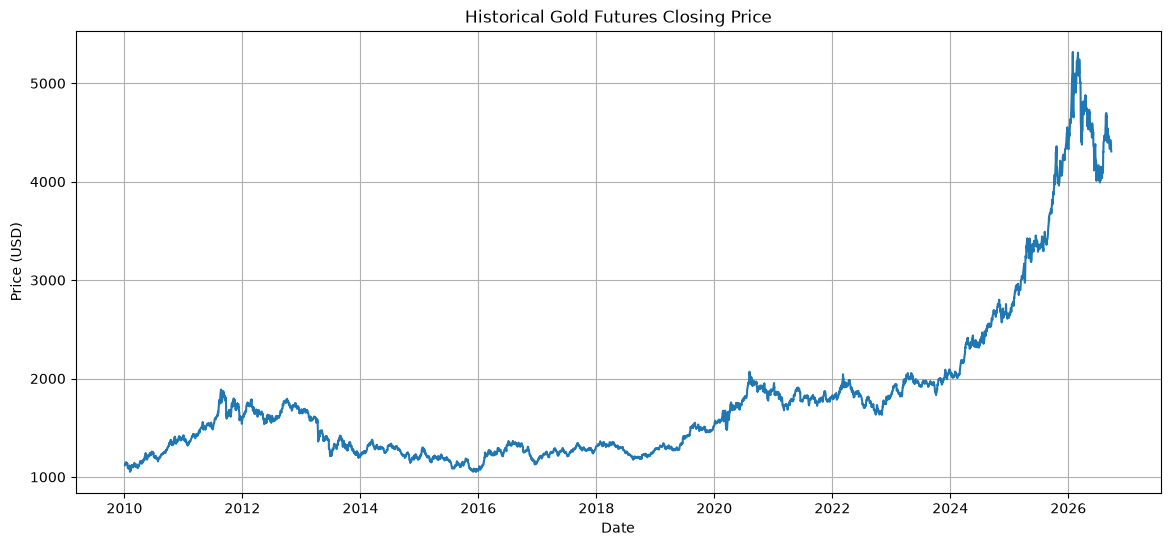

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(gold.index, gold["Close"])

plt.title("Historical Gold Futures Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

plt.show()

In [27]:
processed_file = PROCESSED_DIR / "gold_clean.csv"

gold.to_csv(processed_file)

print(f"Processed data saved successfully:\n{processed_file}")

Processed data saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_clean.csv


## Phase 2 Summary

The raw gold futures dataset was cleaned and prepared for financial
time-series analysis.

The following steps were completed:

- Simplified the MultiIndex column structure
- Selected relevant OHLCV variables
- Prepared the Date index
- Checked missing values
- Checked duplicate dates
- Validated price values
- Verified chronological ordering
- Generated descriptive statistics
- Visualized the historical closing price
- Saved the processed dataset

The cleaned dataset is now ready for return calculation and volatility analysis.

# Phase 3 — Return Analysis

In this phase, historical gold price data is transformed into daily
returns and log returns.

Returns are the primary input for volatility and financial risk analysis.

The main objectives are:

- Calculate daily percentage returns
- Calculate logarithmic returns
- Compare the two return measures
- Analyze return distribution
- Calculate descriptive statistics
- Prepare the dataset for volatility modeling

In [29]:
processed_file = PROCESSED_DIR / "gold_clean.csv"

gold = pd.read_csv(
    processed_file,
    parse_dates=["Date"],
    index_col="Date"
)

gold.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## Daily Return

Daily return measures the percentage change in the closing price
from one trading day to the next.

In [30]:
gold["Daily_Return"] = gold["Close"].pct_change()

gold[["Close", "Daily_Return"]].head(10)

,Close,Daily_Return
Date,,
2010-01-04,1117.699951,NaN
2010-01-05,1118.099976,0.000358
2010-01-06,1135.900024,0.015920
2010-01-07,1133.099976,-0.002465
2010-01-08,1138.199951,0.004501
2010-01-11,1150.699951,0.010982
2010-01-12,1128.900024,-0.018945
2010-01-13,1136.400024,0.006644
2010-01-14,1142.599976,0.005456


## Log Return

Log return is calculated as the natural logarithm of the ratio
between the current closing price and the previous closing price.

Log returns are commonly used in financial time-series analysis
because they are additive over time.

In [31]:
gold["Log_Return"] = np.log(
    gold["Close"] / gold["Close"].shift(1)
)

gold[["Close", "Daily_Return", "Log_Return"]].head(10)

,Close,Daily_Return,Log_Return
Date,,,
2010-01-04,1117.699951,NaN,NaN
2010-01-05,1118.099976,0.000358,0.000358
2010-01-06,1135.900024,0.015920,0.015795
2010-01-07,1133.099976,-0.002465,-0.002468
2010-01-08,1138.199951,0.004501,0.004491
2010-01-11,1150.699951,0.010982,0.010922
2010-01-12,1128.900024,-0.018945,-0.019127
2010-01-13,1136.400024,0.006644,0.006622
2010-01-14,1142.599976,0.005456,0.005441


In [32]:
gold[["Daily_Return", "Log_Return"]].isnull().sum()

Daily_Return    1
Log_Return      1
dtype: int64

## Return Statistics

Descriptive statistics are calculated to understand the central tendency,
dispersion, and distribution characteristics of gold returns.

In [33]:
return_stats = gold[
    ["Daily_Return", "Log_Return"]
].describe()

return_stats

,Daily_Return,Log_Return
count,4206.000000,4206.000000
mean,0.000380,0.000321
std,0.010838,0.010875
min,-0.107796,-0.114060
25%,-0.004671,-0.004682
50%,0.000428,0.000428
75%,0.005978,0.005960
max,0.060697,0.058926


In [34]:
return_distribution = pd.DataFrame({
    "Mean": gold[["Daily_Return", "Log_Return"]].mean(),
    "Std": gold[["Daily_Return", "Log_Return"]].std(),
    "Skewness": gold[["Daily_Return", "Log_Return"]].skew(),
    "Kurtosis": gold[["Daily_Return", "Log_Return"]].kurt()
})

return_distribution

,Mean,Std,Skewness,Kurtosis
Daily_Return,0.000380,0.010838,-0.599546,6.697263
Log_Return,0.000321,0.010875,-0.741513,7.551093


## Daily Return Time Series

The daily return series is visualized to identify periods of unusually
large positive or negative movements.

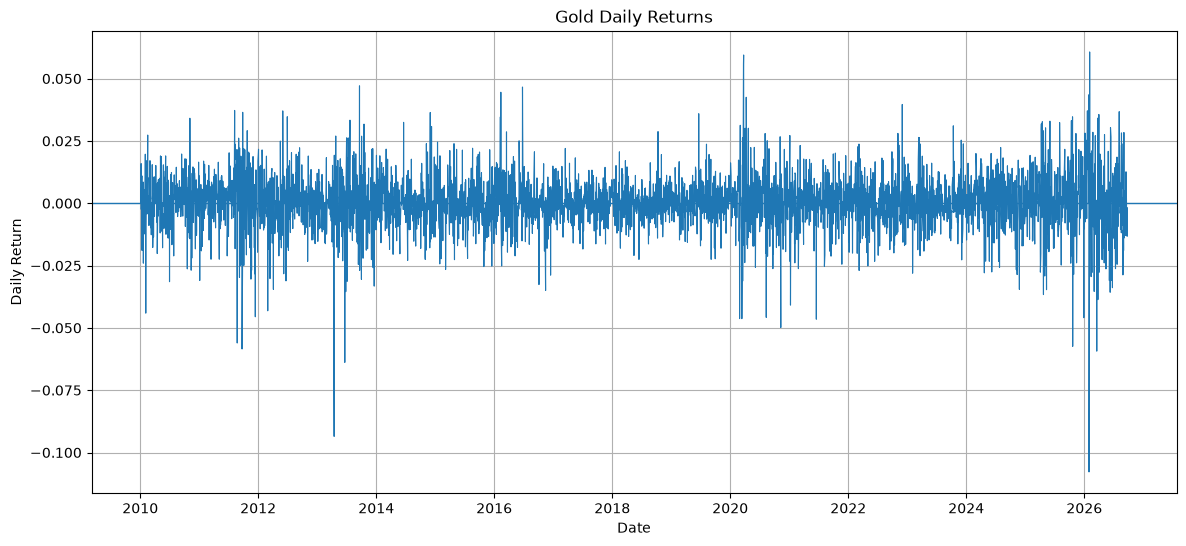

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Daily_Return"],
    linewidth=0.8
)

plt.title("Gold Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.axhline(0, linewidth=1)

plt.grid(True)
plt.show()

## Distribution of Daily Returns

The distribution of daily returns is examined to evaluate its shape,
dispersion, and potential deviation from a normal distribution.

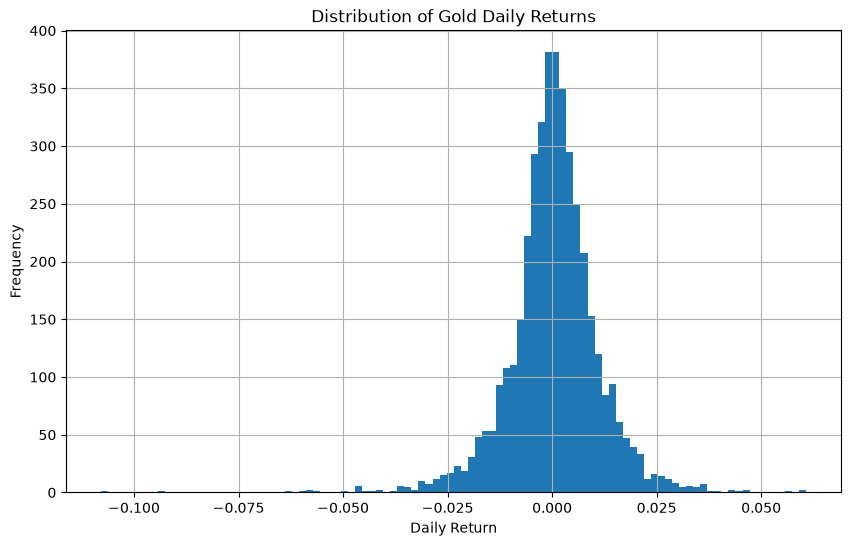

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    gold["Daily_Return"].dropna(),
    bins=100
)

plt.title("Distribution of Gold Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

In [37]:
largest_positive = gold["Daily_Return"].nlargest(10)

largest_negative = gold["Daily_Return"].nsmallest(10)

print("Largest Positive Returns:")
display(largest_positive)

print("\nLargest Negative Returns:")
display(largest_negative)

Largest Positive Returns:


Date
2026-02-03    0.060697
2020-03-24    0.059477
2020-03-23    0.055930
2013-09-19    0.047102
2016-06-24    0.046622
2016-02-11    0.044530
2026-01-28    0.043482
2020-04-09    0.042512
2022-12-01    0.039633
2011-08-08    0.037239
Name: Daily_Return, dtype: float64


Largest Negative Returns:


Date
2026-01-30   -0.107796
2013-04-15   -0.093538
2013-06-20   -0.063847
2026-03-19   -0.059332
2011-09-23   -0.058475
2025-10-21   -0.057416
2011-08-24   -0.056073
2020-11-09   -0.049854
2021-06-17   -0.046524
2020-03-13   -0.046310
Name: Daily_Return, dtype: float64

In [38]:
returns_file = PROCESSED_DIR / "gold_returns.csv"

gold.to_csv(returns_file)

print(f"Return dataset saved successfully:\n{returns_file}")

Return dataset saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_returns.csv


## Phase 3 Summary

Daily and logarithmic returns were calculated from historical gold
closing prices.

The return series was analyzed using:

- Descriptive statistics
- Standard deviation
- Skewness
- Kurtosis
- Time-series visualization
- Return distribution
- Extreme positive and negative returns

The resulting dataset has been saved as `gold_returns.csv`.

This dataset will be used in the next phase for historical and
rolling volatility analysis.

# Phase 4 — Volatility Analysis

In this phase, the volatility of gold returns is analyzed using
historical and rolling volatility measures.

The main objectives are:

- Calculate historical daily volatility
- Calculate rolling volatility
- Annualize volatility
- Compare short-term and medium-term volatility
- Identify periods of volatility clustering
- Prepare the return series for GARCH modeling

In [41]:
returns_file = PROCESSED_DIR / "gold_returns.csv"

gold = pd.read_csv(
    returns_file,
    parse_dates=["Date"],
    index_col="Date"
)

gold.head()

,Open,High,Low,Close,Volume,Daily_Return,Log_Return
Date,,,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184,NaN,NaN
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,0.000358,0.000358
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,0.015920,0.015795
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,-0.002465,-0.002468
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,0.004501,0.004491


## Historical Volatility

Historical volatility is measured using the standard deviation
of daily returns.

This provides a single measure of the overall dispersion of
gold daily returns across the sample period.

In [42]:
daily_volatility = gold["Daily_Return"].std()

print(f"Daily Historical Volatility: {daily_volatility:.6%}")

Daily Historical Volatility: 1.083789%


## Annualized Volatility

Daily volatility is annualized using 252 trading days per year.

Annualized volatility allows the volatility measure to be expressed
on a yearly basis.

In [43]:
annualized_volatility = daily_volatility * np.sqrt(252)

print(f"Annualized Volatility: {annualized_volatility:.6%}")

Annualized Volatility: 17.204615%


## Rolling Volatility

Rolling volatility measures how return dispersion changes over time.

Two rolling windows are used:

- 7 trading days — short-term volatility
- 30 trading days — medium-term volatility

In [44]:
gold["Volatility_7D"] = (
    gold["Daily_Return"]
    .rolling(window=7)
    .std()
)

gold["Volatility_30D"] = (
    gold["Daily_Return"]
    .rolling(window=30)
    .std()
)

gold[[
    "Daily_Return",
    "Volatility_7D",
    "Volatility_30D"
]].tail()

,Daily_Return,Volatility_7D,Volatility_30D
Date,,,
2026-09-18,0.005728,0.009319,0.013596
2026-09-21,-0.009266,0.008838,0.013048
2026-09-22,-0.001711,0.008830,0.013023
2026-09-23,-0.013253,0.008903,0.013197
2026-09-24,-0.002547,0.008816,0.013137


In [45]:
gold["Annualized_Volatility_7D"] = (
    gold["Volatility_7D"] * np.sqrt(252)
)

gold["Annualized_Volatility_30D"] = (
    gold["Volatility_30D"] * np.sqrt(252)
)

gold[[
    "Annualized_Volatility_7D",
    "Annualized_Volatility_30D"
]].tail()

,Annualized_Volatility_7D,Annualized_Volatility_30D
Date,,
2026-09-18,0.147939,0.215835
2026-09-21,0.140292,0.207138
2026-09-22,0.140167,0.206729
2026-09-23,0.141333,0.209492
2026-09-24,0.139942,0.208543


## Rolling Volatility Over Time

Rolling volatility is visualized to identify periods of elevated
and subdued market risk.

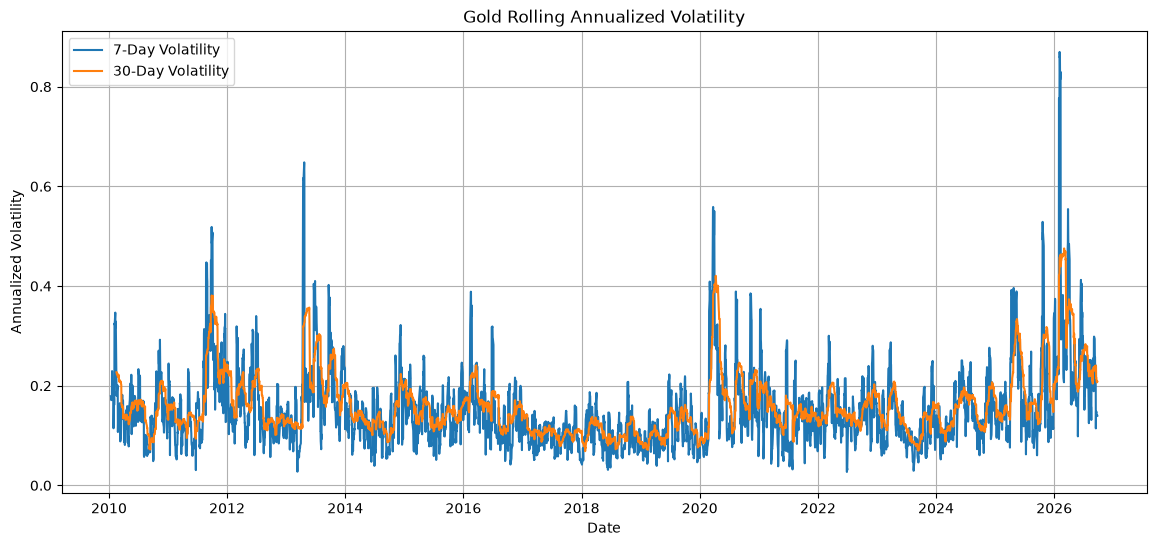

In [46]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_7D"],
    label="7-Day Volatility"
)

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30-Day Volatility"
)

plt.title("Gold Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.legend()
plt.grid(True)

plt.show()

In [47]:
volatility_stats = gold[
    [
        "Volatility_7D",
        "Volatility_30D",
        "Annualized_Volatility_7D",
        "Annualized_Volatility_30D"
    ]
].describe()

volatility_stats

,Volatility_7D,Volatility_30D,Annualized_Volatility_7D,Annualized_Volatility_30D
count,4200.000000,4177.000000,4200.000000,4177.000000
mean,0.009624,0.010101,0.152774,0.160347
std,0.005146,0.003992,0.081691,0.063364
min,0.001698,0.004324,0.026953,0.068639
25%,0.006264,0.007551,0.099436,0.119862
50%,0.008498,0.009101,0.134909,0.144479
75%,0.011558,0.011480,0.183470,0.182233
max,0.054785,0.029950,0.869691,0.475444


## Highest Volatility Periods

The periods with the highest observed rolling volatility are identified
to investigate major volatility regimes in the gold futures market.

In [48]:
top_volatility_periods = (
    gold["Annualized_Volatility_30D"]
    .nlargest(10)
)

top_volatility_periods

Date
2026-03-03    0.475444
2026-03-11    0.469699
2026-03-10    0.468079
2026-03-09    0.465364
2026-03-06    0.465258
2026-03-05    0.465242
2026-03-04    0.465042
2026-02-24    0.464740
2026-02-10    0.463448
2026-02-23    0.462799
Name: Annualized_Volatility_30D, dtype: float64

## Absolute Returns and Volatility

Absolute returns are compared with rolling volatility.

Large absolute returns are expected to be associated with periods
of elevated volatility.

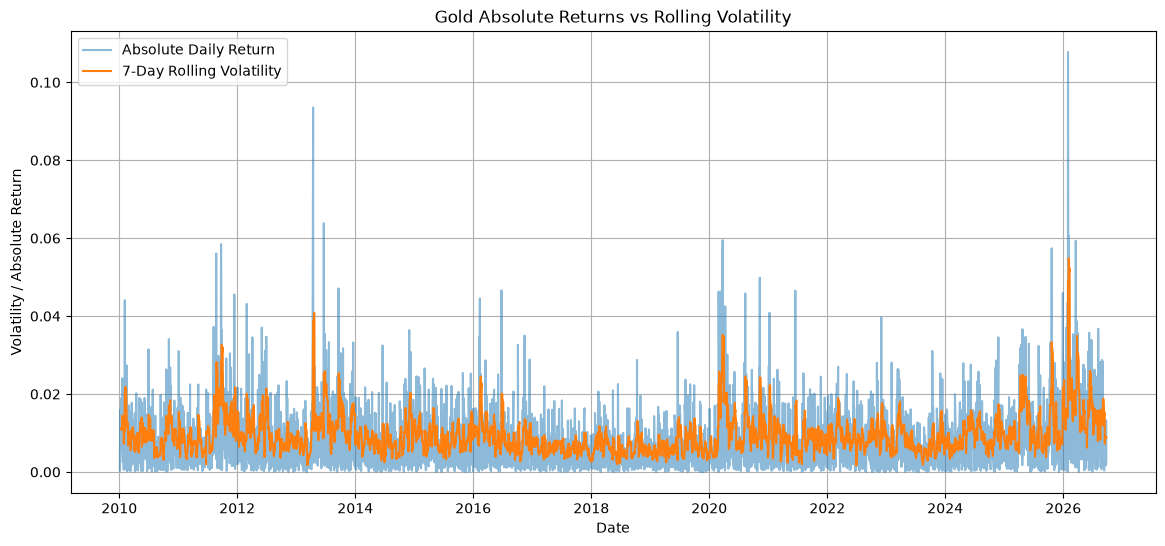

In [49]:
gold["Absolute_Return"] = gold["Daily_Return"].abs()

plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Absolute_Return"],
    label="Absolute Daily Return",
    alpha=0.5
)

plt.plot(
    gold.index,
    gold["Volatility_7D"],
    label="7-Day Rolling Volatility"
)

plt.title("Gold Absolute Returns vs Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility / Absolute Return")

plt.legend()
plt.grid(True)

plt.show()

In [50]:
volatility_correlation = gold[
    ["Absolute_Return", "Volatility_7D"]
].corr()

volatility_correlation

,Absolute_Return,Volatility_7D
Absolute_Return,1.00000,0.46612
Volatility_7D,0.46612,1.00000


In [51]:
volatility_file = PROCESSED_DIR / "gold_volatility.csv"

gold.to_csv(volatility_file)

print(f"Volatility dataset saved successfully:\n{volatility_file}")

Volatility dataset saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_volatility.csv


## Phase 4 Summary

Gold volatility was analyzed using historical and rolling volatility
measures.

The analysis included:

- Historical daily volatility
- Annualized volatility
- 7-day rolling volatility
- 30-day rolling volatility
- Volatility regime identification
- Absolute return analysis
- Volatility correlation analysis

The results provide an initial view of time-varying volatility and
volatility clustering in gold futures returns.

The resulting dataset has been saved as `gold_volatility.csv`.

The next phase will use GARCH modeling to formally model the
conditional volatility of gold returns.

In [52]:
print(f"Daily Historical Volatility: {daily_volatility:.6%}")
print(f"Annualized Volatility: {annualized_volatility:.6%}")

Daily Historical Volatility: 1.083789%
Annualized Volatility: 17.204615%


In [53]:
print(volatility_stats.to_string())

       Volatility_7D  Volatility_30D  Annualized_Volatility_7D  Annualized_Volatility_30D
count    4200.000000     4177.000000               4200.000000                4177.000000
mean        0.009624        0.010101                  0.152774                   0.160347
std         0.005146        0.003992                  0.081691                   0.063364
min         0.001698        0.004324                  0.026953                   0.068639
25%         0.006264        0.007551                  0.099436                   0.119862
50%         0.008498        0.009101                  0.134909                   0.144479
75%         0.011558        0.011480                  0.183470                   0.182233
max         0.054785        0.029950                  0.869691                   0.475444


In [54]:
print(top_volatility_periods.to_string())

Date
2026-03-03    0.475444
2026-03-11    0.469699
2026-03-10    0.468079
2026-03-09    0.465364
2026-03-06    0.465258
2026-03-05    0.465242
2026-03-04    0.465042
2026-02-24    0.464740
2026-02-10    0.463448
2026-02-23    0.462799


In [55]:
print(volatility_correlation.to_string())

                 Absolute_Return  Volatility_7D
Absolute_Return          1.00000        0.46612
Volatility_7D            0.46612        1.00000


## Phase 5 — GARCH(1,1) Volatility Modeling

In this phase, a GARCH(1,1) model is fitted to gold log returns
to estimate and model time-varying conditional volatility.

The GARCH model is defined as:

σ²ₜ = ω + αε²ₜ₋₁ + βσ²ₜ₋₁

where:
- ω represents the long-term variance component.
- α measures the impact of recent shocks.
- β measures volatility persistence.
- α + β indicates the persistence of volatility.

In [58]:
returns = gold["Log_Return"].dropna() * 100

returns.describe()

count    4206.000000
mean        0.032075
std         1.087461
min       -11.405996
25%        -0.468199
50%         0.042822
75%         0.595985
max         5.892645
Name: Log_Return, dtype: float64

In [59]:
garch_model = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_result = garch_model.fit(disp="off")

print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6016.30
Distribution:                  Normal   AIC:                           12040.6
Method:            Maximum Likelihood   BIC:                           12066.0
                                        No. Observations:                 4206
Date:                Fri, Sep 25 2026   Df Residuals:                     4205
Time:                        00:31:58   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0212  1.533e-02      1.382      0.167 

### GARCH Volatility Persistence

The persistence of volatility is measured by the sum of the ARCH
and GARCH coefficients:

Persistence = α₁ + β₁

A value close to 1 indicates that volatility shocks tend to persist
for a relatively long period.

In [60]:
omega = garch_result.params["omega"]
alpha = garch_result.params["alpha[1]"]
beta = garch_result.params["beta[1]"]

persistence = alpha + beta

print(f"Omega: {omega:.4f}")
print(f"Alpha: {alpha:.4f}")
print(f"Beta: {beta:.4f}")
print(f"Volatility Persistence (α + β): {persistence:.4f}")

Omega: 0.0178
Alpha: 0.0504
Beta: 0.9350
Volatility Persistence (α + β): 0.9854


In [61]:
gold["GARCH_Volatility"] = np.nan

gold.loc[returns.index, "GARCH_Volatility"] = (
    garch_result.conditional_volatility
)

gold[["Log_Return", "GARCH_Volatility"]].tail()

,Log_Return,GARCH_Volatility
Date,,
2026-09-18,0.005711,1.281791
2026-09-21,-0.009309,1.252670
2026-09-22,-0.001712,1.237178
2026-09-23,-0.013342,1.204467
2026-09-24,-0.002550,1.211094


In [62]:
gold["GARCH_Annualized_Volatility"] = (
    gold["GARCH_Volatility"] * np.sqrt(252)
)

gold[["GARCH_Volatility", "GARCH_Annualized_Volatility"]].describe()

,GARCH_Volatility,GARCH_Annualized_Volatility
count,4206.000000,4206.000000
mean,1.046621,16.614593
std,0.307736,4.885162
min,0.646930,10.269695
25%,0.849436,13.484377
50%,0.966083,15.336094
75%,1.144539,18.169000
max,3.159839,50.160888


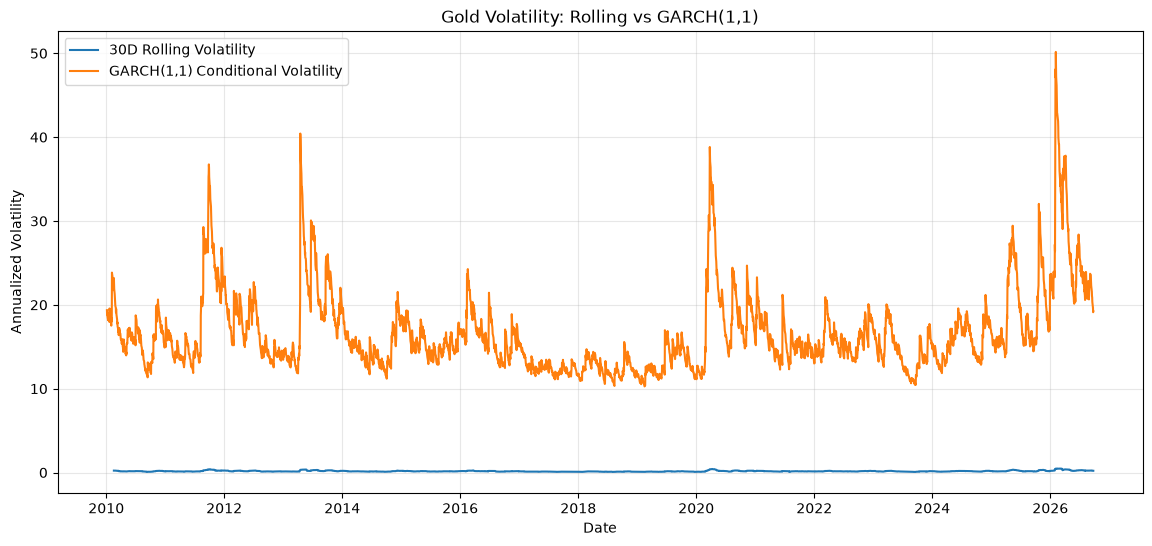

In [63]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30D Rolling Volatility"
)

plt.plot(
    gold.index,
    gold["GARCH_Annualized_Volatility"],
    label="GARCH(1,1) Conditional Volatility"
)

plt.title("Gold Volatility: Rolling vs GARCH(1,1)")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [64]:
gold["GARCH_Volatility"] = np.nan

gold.loc[returns.index, "GARCH_Volatility"] = (
    garch_result.conditional_volatility
)

gold["GARCH_Annualized_Volatility"] = (
    gold["GARCH_Volatility"] * np.sqrt(252)
)

print(gold[[
    "GARCH_Volatility",
    "GARCH_Annualized_Volatility"
]].describe())

       GARCH_Volatility  GARCH_Annualized_Volatility
count       4206.000000                  4206.000000
mean           1.046621                    16.614593
std            0.307736                     4.885162
min            0.646930                    10.269695
25%            0.849436                    13.484377
50%            0.966083                    15.336094
75%            1.144539                    18.169000
max            3.159839                    50.160888


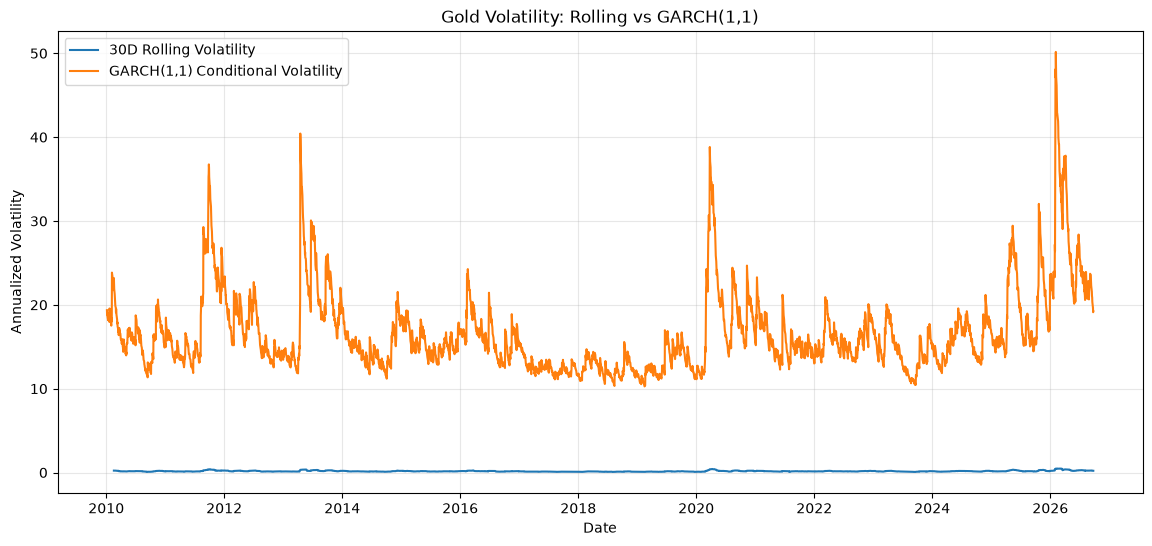

In [65]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30D Rolling Volatility"
)

plt.plot(
    gold.index,
    gold["GARCH_Annualized_Volatility"],
    label="GARCH(1,1) Conditional Volatility"
)

plt.title("Gold Volatility: Rolling vs GARCH(1,1)")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### GARCH Model Diagnostics

Standardized residuals are examined to evaluate whether the GARCH model
has adequately captured the time-varying volatility structure.

In [66]:
standardized_residuals = garch_result.std_resid

standardized_residuals.describe()

count    4206.000000
mean        0.011414
std         1.000320
min        -7.552725
25%        -0.497105
50%         0.023046
75%         0.572642
max         4.997880
Name: std_resid, dtype: float64

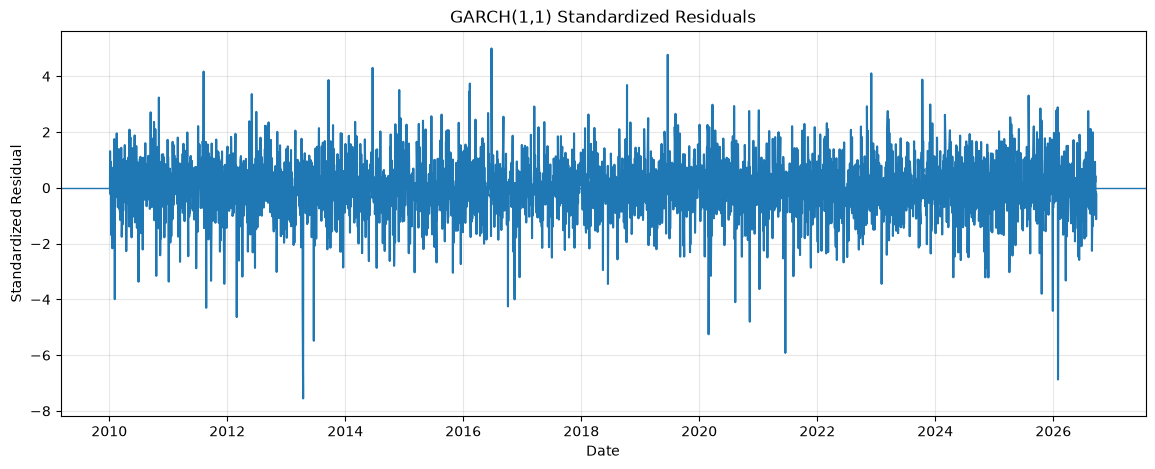

In [67]:
plt.figure(figsize=(14, 5))

plt.plot(
    standardized_residuals.index,
    standardized_residuals
)

plt.axhline(0, linewidth=1)

plt.title("GARCH(1,1) Standardized Residuals")
plt.xlabel("Date")
plt.ylabel("Standardized Residual")

plt.grid(alpha=0.3)
plt.show()

In [68]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    standardized_residuals.dropna() ** 2,
    lags=[10, 20],
    return_df=True
)

lb_test

,lb_stat,lb_pvalue
10,7.387589,0.688417
20,11.773047,0.923666


In [69]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Standardized residuals
standardized_residuals = garch_result.std_resid

print("=== Standardized Residuals ===")
print(standardized_residuals.describe())

# Ljung-Box test on squared standardized residuals
lb_test = acorr_ljungbox(
    standardized_residuals.dropna() ** 2,
    lags=[10, 20],
    return_df=True
)

print("\n=== Ljung-Box Test on Squared Standardized Residuals ===")
print(lb_test)

=== Standardized Residuals ===
count    4206.000000
mean        0.011414
std         1.000320
min        -7.552725
25%        -0.497105
50%         0.023046
75%         0.572642
max         4.997880
Name: std_resid, dtype: float64

=== Ljung-Box Test on Squared Standardized Residuals ===
      lb_stat  lb_pvalue
10   7.387589   0.688417
20  11.773047   0.923666


### GARCH(1,1) with Student-t Distribution

The return distribution showed significant excess kurtosis and fat tails.
Therefore, a second GARCH(1,1) model is estimated using a Student-t
distribution instead of the normal distribution.

The models are compared using AIC and BIC.

In [70]:
garch_t_model = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_t_result = garch_t_model.fit(disp="off")

print(garch_t_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   Log_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5794.55
Distribution:      Standardized Student's t   AIC:                           11599.1
Method:                  Maximum Likelihood   BIC:                           11630.8
                                              No. Observations:                 4206
Date:                      Fri, Sep 25 2026   Df Residuals:                     4205
Time:                              00:38:49   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [71]:
comparison = pd.DataFrame({
    "Model": [
        "GARCH(1,1) - Normal",
        "GARCH(1,1) - Student-t"
    ],
    "Log_Likelihood": [
        garch_result.loglikelihood,
        garch_t_result.loglikelihood
    ],
    "AIC": [
        garch_result.aic,
        garch_t_result.aic
    ],
    "BIC": [
        garch_result.bic,
        garch_t_result.bic
    ],
    "Alpha": [
        garch_result.params["alpha[1]"],
        garch_t_result.params["alpha[1]"]
    ],
    "Beta": [
        garch_result.params["beta[1]"],
        garch_t_result.params["beta[1]"]
    ],
    "Persistence": [
        garch_result.params["alpha[1]"] + garch_result.params["beta[1]"],
        garch_t_result.params["alpha[1]"] + garch_t_result.params["beta[1]"]
    ]
})

comparison

,Model,Log_Likelihood,AIC,BIC,Alpha,Beta,Persistence
0,"GARCH(1,1) - Normal",-6016.304066,12040.608132,12065.985202,0.050384,0.934984,0.985367
1,"GARCH(1,1) - Student-t",-5794.550536,11599.101071,11630.822408,0.035391,0.958100,0.993492


### Final GARCH Model Selection

Two GARCH(1,1) specifications were evaluated using Normal and
Student-t innovations.

The Student-t specification produced lower AIC and BIC values
and a higher log-likelihood than the Normal specification.

Given the heavy-tailed characteristics observed in gold returns,
the Student-t GARCH(1,1) model is selected as the primary volatility
model for the subsequent risk analysis.

In [72]:
gold["GARCH_T_Volatility"] = np.nan

gold.loc[returns.index, "GARCH_T_Volatility"] = (
    garch_t_result.conditional_volatility
)

gold["GARCH_T_Annualized_Volatility"] = (
    gold["GARCH_T_Volatility"] * np.sqrt(252)
)

print(
    gold[
        [
            "GARCH_T_Volatility",
            "GARCH_T_Annualized_Volatility"
        ]
    ].describe()
)

       GARCH_T_Volatility  GARCH_T_Annualized_Volatility
count         4206.000000                    4206.000000
mean             1.065860                      16.919995
std              0.305832                       4.854935
min              0.650725                      10.329938
25%              0.867329                      13.768422
50%              0.987485                      15.675842
75%              1.167959                      18.540775
max              2.815569                      44.695770


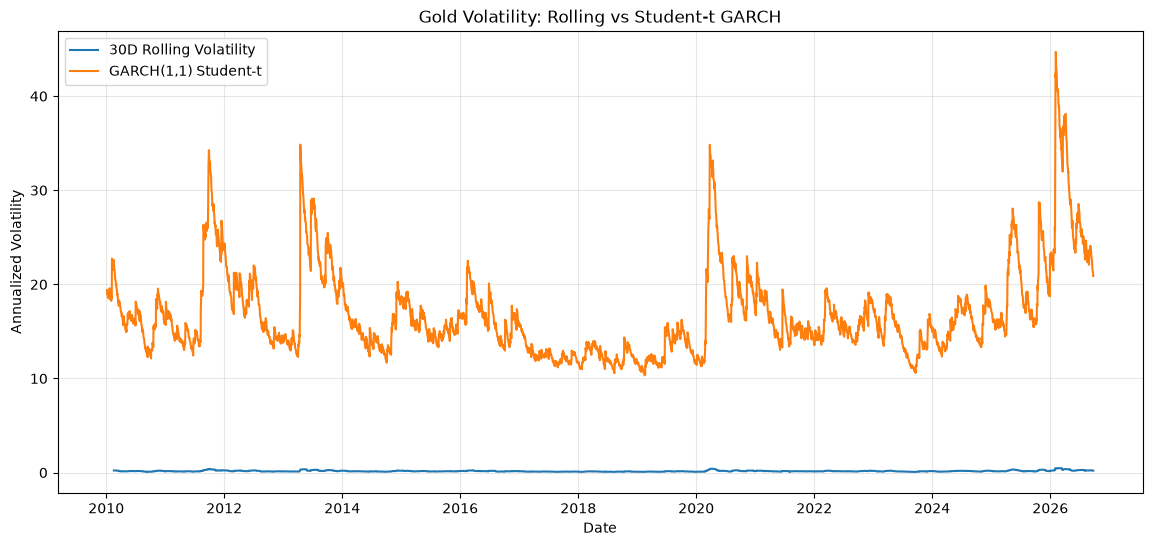

In [73]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30D Rolling Volatility"
)

plt.plot(
    gold.index,
    gold["GARCH_T_Annualized_Volatility"],
    label="GARCH(1,1) Student-t"
)

plt.title("Gold Volatility: Rolling vs Student-t GARCH")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [74]:
volatility_file = PROCESSED_DIR / "gold_volatility.csv"

gold.to_csv(volatility_file)

print(f"Saved to: {volatility_file}")

Saved to: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_volatility.csv


# Phase 6 — Value at Risk (VaR) & Expected Shortfall (ES)

This phase focuses on measuring downside risk in gold returns.

Two risk measures are calculated:

- Value at Risk (VaR)
- Expected Shortfall (ES)

Historical simulation is used first, based on the empirical distribution
of historical gold log returns.

In [75]:
returns = gold["Log_Return"].dropna()

print(f"Number of observations: {len(returns)}")
print(f"Mean daily return: {returns.mean():.4%}")
print(f"Daily volatility: {returns.std():.4%}")

Number of observations: 4206
Mean daily return: 0.0321%
Daily volatility: 1.0875%


## Historical VaR and Expected Shortfall

Historical VaR estimates the return threshold corresponding to a given
confidence level using the empirical distribution of historical returns.

Expected Shortfall measures the average return beyond the VaR threshold.

VaR and ES are reported as positive loss magnitudes.

In [76]:
confidence_levels = [0.95, 0.99]

risk_results = []

for confidence in confidence_levels:
    
    alpha = 1 - confidence
    
    var_threshold = returns.quantile(alpha)
    
    tail_returns = returns[returns <= var_threshold]
    
    var_loss = -var_threshold
    es_loss = -tail_returns.mean()
    
    risk_results.append({
        "Confidence": f"{int(confidence * 100)}%",
        "VaR": var_loss,
        "ES": es_loss
    })

risk_results_df = pd.DataFrame(risk_results)

risk_results_df

,Confidence,VaR,ES
0,95%,0.017138,0.026290
1,99%,0.030673,0.043533


### Interpretation

The historical VaR represents the estimated daily loss threshold
at the selected confidence level.

Expected Shortfall represents the average loss conditional on returns
falling beyond the corresponding VaR threshold.

As the confidence level increases from 95% to 99%, both VaR and ES
are expected to increase because the analysis moves further into
the left tail of the return distribution.

## GARCH-Based Conditional VaR

Historical VaR uses the unconditional historical distribution of returns.

In contrast, GARCH-based VaR incorporates time-varying conditional volatility.

The Student-t GARCH(1,1) model selected in Phase 5 is used to estimate
conditional volatility and construct a dynamic VaR measure.

In [77]:
garch_volatility = gold["GARCH_T_Volatility"].dropna()

print(garch_volatility.describe())

count    4206.000000
mean        1.065860
std         0.305832
min         0.650725
25%         0.867329
50%         0.987485
75%         1.167959
max         2.815569
Name: GARCH_T_Volatility, dtype: float64


## Dynamic VaR Using Student-t GARCH

The Student-t GARCH model provides a time-varying estimate of conditional
volatility.

Using the estimated Student-t distribution and conditional volatility,
a dynamic VaR threshold can be calculated for each trading day.

This allows the estimated downside risk to change as market volatility changes.

In [78]:
from scipy.stats import t

# Student-t degrees of freedom
nu = garch_t_result.params["nu"]

# Standardized Student-t quantiles
q_95 = t.ppf(0.05, df=nu)
q_99 = t.ppf(0.01, df=nu)

print(f"Degrees of Freedom (nu): {nu:.4f}")
print(f"5% Student-t Quantile: {q_95:.4f}")
print(f"1% Student-t Quantile: {q_99:.4f}")

Degrees of Freedom (nu): 4.2340
5% Student-t Quantile: -2.0984
1% Student-t Quantile: -3.6351


## Standardized Student-t Quantiles

The `arch` package uses a standardized Student-t distribution for the
innovation process.

Therefore, the raw SciPy Student-t quantiles must be adjusted by:

sqrt((nu - 2) / nu)

to obtain the corresponding standardized quantiles used by the GARCH model.

In [79]:
from scipy.stats import t
import numpy as np

nu = garch_t_result.params["nu"]

# Standardization factor used for the Student-t distribution
scale_factor = np.sqrt((nu - 2) / nu)

# Standardized quantiles
q_95_standardized = t.ppf(0.05, df=nu) * scale_factor
q_99_standardized = t.ppf(0.01, df=nu) * scale_factor

print(f"Degrees of Freedom (nu): {nu:.4f}")
print(f"Standardization Factor: {scale_factor:.4f}")
print(f"Standardized 5% Quantile: {q_95_standardized:.4f}")
print(f"Standardized 1% Quantile: {q_99_standardized:.4f}")

Degrees of Freedom (nu): 4.2340
Standardization Factor: 0.7264
Standardized 5% Quantile: -1.5243
Standardized 1% Quantile: -2.6405


In [80]:
gold["VaR_95_GARCH"] = np.nan
gold["VaR_99_GARCH"] = np.nan

gold.loc[returns.index, "VaR_95_GARCH"] = (
    gold.loc[returns.index, "GARCH_T_Volatility"]
    * q_95_standardized
)

gold.loc[returns.index, "VaR_99_GARCH"] = (
    gold.loc[returns.index, "GARCH_T_Volatility"]
    * q_99_standardized
)

print(
    gold[
        ["VaR_95_GARCH", "VaR_99_GARCH"]
    ].describe()
)

       VaR_95_GARCH  VaR_99_GARCH
count   4206.000000   4206.000000
mean      -1.624663     -2.814359
std        0.466172      0.807537
min       -4.291701     -7.434395
25%       -1.780291     -3.083948
50%       -1.505199     -2.607415
75%       -1.322048     -2.290147
max       -0.991884     -1.718213


## GARCH VaR as Loss Magnitude

For risk reporting, VaR is expressed as a positive loss magnitude.

A higher value therefore represents a larger estimated downside risk.

In [81]:
gold["GARCH_VaR_95_Loss"] = -gold["VaR_95_GARCH"]
gold["GARCH_VaR_99_Loss"] = -gold["VaR_99_GARCH"]

print("Average GARCH VaR:")
print(f"95% VaR: {gold['GARCH_VaR_95_Loss'].mean():.4%}")
print(f"99% VaR: {gold['GARCH_VaR_99_Loss'].mean():.4%}")

print("\nMaximum GARCH VaR:")
print(f"95% VaR: {gold['GARCH_VaR_95_Loss'].max():.4%}")
print(f"99% VaR: {gold['GARCH_VaR_99_Loss'].max():.4%}")

Average GARCH VaR:
95% VaR: 162.4663%
99% VaR: 281.4359%

Maximum GARCH VaR:
95% VaR: 429.1701%
99% VaR: 743.4395%


## Dynamic Expected Shortfall

Expected Shortfall estimates the average loss beyond the VaR threshold.

For the Student-t GARCH model, ES is calculated using the conditional
volatility and the standardized Student-t distribution.

This provides a time-varying estimate of extreme downside risk.

In [82]:
from scipy.stats import t
import numpy as np

nu = garch_t_result.params["nu"]

# Standardization factor
scale_factor = np.sqrt((nu - 2) / nu)

# Raw Student-t quantiles
q95_raw = t.ppf(0.05, df=nu)
q99_raw = t.ppf(0.01, df=nu)

# Standardized quantiles
q95 = q95_raw * scale_factor
q99 = q99_raw * scale_factor

# Student-t PDF at the quantiles
pdf95 = t.pdf(q95_raw, df=nu)
pdf99 = t.pdf(q99_raw, df=nu)

# ES of standardized Student-t distribution
es95_standardized = -(
    scale_factor
    * ((nu + q95_raw**2) / (nu - 1))
    * (pdf95 / 0.05)
)

es99_standardized = -(
    scale_factor
    * ((nu + q99_raw**2) / (nu - 1))
    * (pdf99 / 0.01)
)

print(f"Standardized 95% ES: {es95_standardized:.4f}")
print(f"Standardized 99% ES: {es99_standardized:.4f}")

Standardized 95% ES: -2.2595
Standardized 99% ES: -3.6243


In [83]:
gold["ES_95_GARCH"] = np.nan
gold["ES_99_GARCH"] = np.nan

gold.loc[returns.index, "ES_95_GARCH"] = (
    gold.loc[returns.index, "GARCH_T_Volatility"]
    * es95_standardized
)

gold.loc[returns.index, "ES_99_GARCH"] = (
    gold.loc[returns.index, "GARCH_T_Volatility"]
    * es99_standardized
)

print(
    gold[
        ["ES_95_GARCH", "ES_99_GARCH"]
    ].describe()
)

       ES_95_GARCH  ES_99_GARCH
count  4206.000000  4206.000000
mean     -2.408344    -3.863046
std       0.691038     1.108442
min      -6.361870   -10.204602
25%      -2.639041    -4.233090
50%      -2.231255    -3.578990
75%      -1.959758    -3.143502
max      -1.470334    -2.358454


## GARCH Expected Shortfall as Loss Magnitude

For consistency with risk reporting, Expected Shortfall is expressed
as a positive loss magnitude.

Higher values indicate greater estimated tail risk.

In [85]:
print("Average GARCH Expected Shortfall:")
print(f"95% ES: {gold['GARCH_ES_95_Loss'].mean():.4f}%")
print(f"99% ES: {gold['GARCH_ES_99_Loss'].mean():.4f}%")

print("\nMaximum GARCH Expected Shortfall:")
print(f"95% ES: {gold['GARCH_ES_95_Loss'].max():.4f}%")
print(f"99% ES: {gold['GARCH_ES_99_Loss'].max():.4f}%")

Average GARCH Expected Shortfall:
95% ES: 2.4083%
99% ES: 3.8630%

Maximum GARCH Expected Shortfall:
95% ES: 6.3619%
99% ES: 10.2046%


## Historical vs GARCH-Based VaR

Historical VaR provides a constant risk threshold based on the empirical
distribution of returns.

GARCH-based VaR is dynamic and changes with estimated conditional volatility.

Comparing the two approaches helps illustrate the difference between
unconditional and volatility-dependent risk measurement.

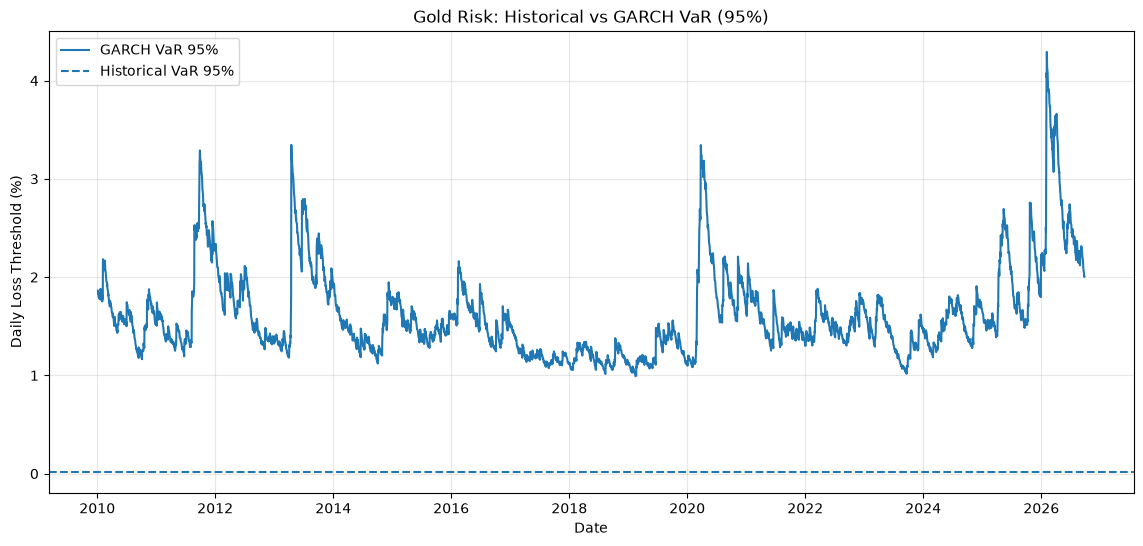

In [86]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    -gold["VaR_95_GARCH"],
    label="GARCH VaR 95%"
)

plt.axhline(
    risk_results_df.loc[
        risk_results_df["Confidence"] == "95%",
        "VaR"
    ].iloc[0],
    linestyle="--",
    label="Historical VaR 95%"
)

plt.title("Gold Risk: Historical vs GARCH VaR (95%)")
plt.xlabel("Date")
plt.ylabel("Daily Loss Threshold (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Historical vs GARCH-Based VaR — 99%

At the 99% confidence level, the comparison becomes more focused on
extreme downside risk.

Historical VaR provides a constant threshold based on the empirical
distribution of historical returns, while GARCH-based VaR changes
over time according to conditional volatility.

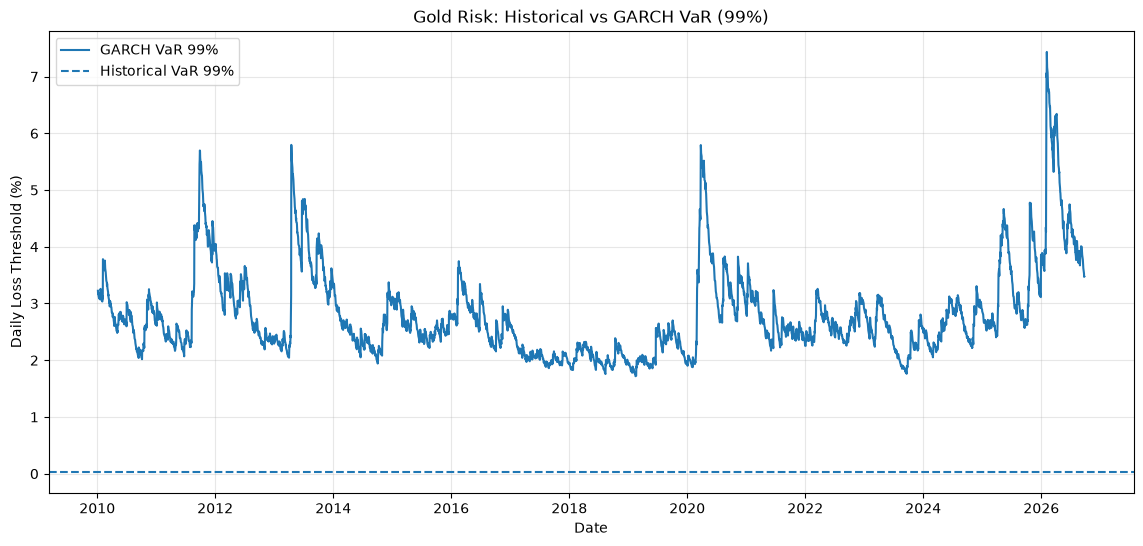

In [88]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    -gold["VaR_99_GARCH"],
    label="GARCH VaR 99%"
)

plt.axhline(
    risk_results_df.loc[
        risk_results_df["Confidence"] == "99%",
        "VaR"
    ].iloc[0],
    linestyle="--",
    label="Historical VaR 99%"
)

plt.title("Gold Risk: Historical vs GARCH VaR (99%)")
plt.xlabel("Date")
plt.ylabel("Daily Loss Threshold (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## GARCH VaR vs Expected Shortfall

Value at Risk defines a threshold for potential downside losses,
while Expected Shortfall estimates the average loss beyond that threshold.

Comparing VaR and ES illustrates the difference between measuring
a risk boundary and measuring the severity of losses in the tail.

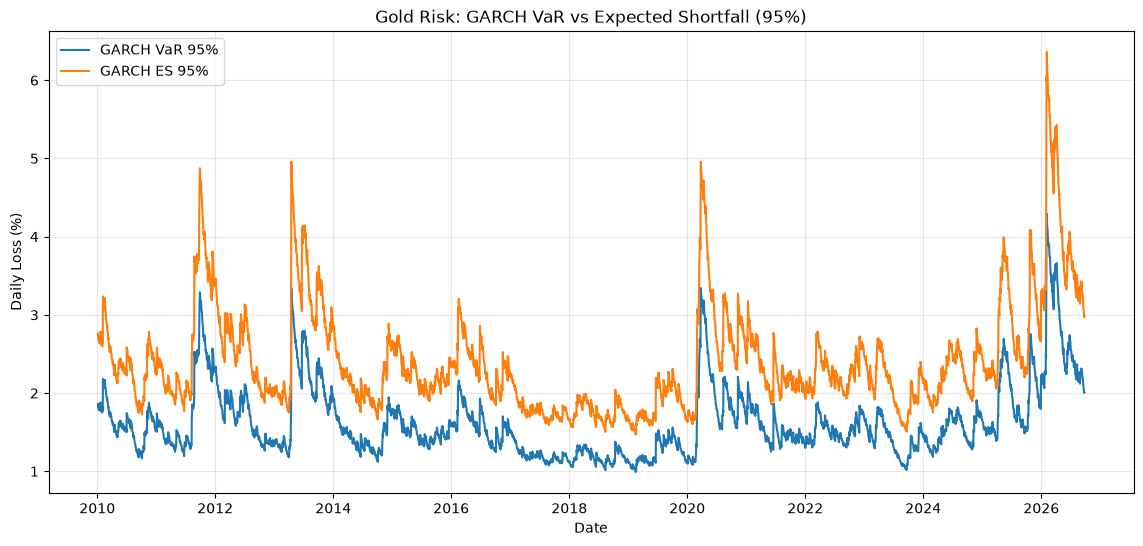

In [89]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["GARCH_VaR_95_Loss"],
    label="GARCH VaR 95%"
)

plt.plot(
    gold.index,
    gold["GARCH_ES_95_Loss"],
    label="GARCH ES 95%"
)

plt.title("Gold Risk: GARCH VaR vs Expected Shortfall (95%)")
plt.xlabel("Date")
plt.ylabel("Daily Loss (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Save Risk Metrics Dataset

The final dataset combines return, volatility, GARCH-based risk measures,
Value at Risk, and Expected Shortfall estimates for further analysis
and reporting.

In [90]:
risk_file = PROCESSED_DIR / "gold_risk_metrics.csv"

gold.to_csv(risk_file)

print(f"Saved to: {risk_file}")

Saved to: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_risk_metrics.csv


## Final Risk Summary

The following table summarizes historical and GARCH-based downside risk
estimates for gold at the 95% and 99% confidence levels.

In [91]:
historical_var_95 = risk_results_df.loc[
    risk_results_df["Confidence"] == "95%", "VaR"
].iloc[0]

historical_es_95 = risk_results_df.loc[
    risk_results_df["Confidence"] == "95%", "ES"
].iloc[0]

historical_var_99 = risk_results_df.loc[
    risk_results_df["Confidence"] == "99%", "VaR"
].iloc[0]

historical_es_99 = risk_results_df.loc[
    risk_results_df["Confidence"] == "99%", "ES"
].iloc[0]

final_risk_summary = pd.DataFrame({
    "Risk Measure": [
        "Historical VaR",
        "GARCH VaR - Average",
        "Historical ES",
        "GARCH ES - Average"
    ],
    "95%": [
        historical_var_95,
        gold["GARCH_VaR_95_Loss"].mean() / 100,
        historical_es_95,
        gold["GARCH_ES_95_Loss"].mean() / 100
    ],
    "99%": [
        historical_var_99,
        gold["GARCH_VaR_99_Loss"].mean() / 100,
        historical_es_99,
        gold["GARCH_ES_99_Loss"].mean() / 100
    ]
})

final_risk_summary.style.format({
    "95%": "{:.4%}",
    "99%": "{:.4%}"
})

,Risk Measure,95%,99%
0,Historical VaR,1.7138%,3.0673%
1,GARCH VaR - Average,1.6247%,2.8144%
2,Historical ES,2.6290%,4.3533%
3,GARCH ES - Average,2.4083%,3.8630%


## Phase 6 — Risk Analysis Interpretation

The historical risk analysis shows that gold futures exhibited meaningful
downside tail risk during the sample period.

At the 95% confidence level, the historical VaR was approximately 1.71%,
while the historical Expected Shortfall was approximately 2.63%.

At the 99% confidence level, historical VaR increased to approximately
3.07%, while Expected Shortfall reached approximately 4.35%.

The GARCH-based estimates were dynamic and incorporated time-varying
conditional volatility. The average GARCH VaR was approximately 1.62%
at the 95% level and 2.81% at the 99% level.

The corresponding average GARCH Expected Shortfall was approximately
2.41% and 3.86%, respectively.

The difference between VaR and Expected Shortfall highlights the
importance of tail-risk analysis. VaR identifies a loss threshold,
whereas ES measures the average severity of losses beyond that threshold.

Overall, the results demonstrate how combining historical risk measures
with a Student-t GARCH model can provide a more dynamic perspective on
gold market risk.